In [1]:
import torch
import os, csv, json, random
import pandas as pd
from tqdm import tqdm
import numpy as np

In [2]:
import shutil
import os

src_dir = '/kaggle/input/smiles-to-iupac'
dst_dir = '/kaggle/working/smiles-to-iupac'

# Copy the whole folder (only once)
if not os.path.exists(dst_dir):
    shutil.copytree(src_dir, dst_dir)

In [3]:
%cd /kaggle/working/smiles-to-iupac/SMILES-to-IUPAC/

/kaggle/working/smiles-to-iupac/SMILES-to-IUPAC


In [4]:
from model.smiles_to_iupac import SMILESToIUPACTransformer
from input_preprocess import SmilesToIUPACPreprocessor
from dataset_preparator import SMILESToIUPACDataModule
from decoder import Decoder
from trainer import Trainer

In [5]:
CSV_PATH = 'data/iupac.csv'
VOCAB_SMILES = 'data/smiles_vocab.json'
VOCAB_IUPAC = 'data/iupac_vocab.json'
CHECKPOINT_PATH = 'history/best_model_v2.pth'
LOG_CSV_PATH = 'history/training_log.csv'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
EPOCHS = 50

In [6]:
os.makedirs('history', exist_ok=True)

In [7]:
preprocessor = SmilesToIUPACPreprocessor(
    raw_csv_path = CSV_PATH,
    smiles_vocab_path=VOCAB_SMILES,
    iupac_vocab_path=VOCAB_IUPAC
)

In [8]:
preprocessor.preprocess_data()
preprocessor.load_and_sample_data(n=100000)
preprocessor.build_and_save_vocabs()
preprocessor.encode_all()
preprocessor.filter_by_length(percentile=95)

Loaded 100000 SMILES-IUPAC pairs
SMILES vocab size: 64
IUPAC vocab size: 62
After filtering: 93661
New SMILES shape: torch.Size([93661, 108])
New IUPAC shape: torch.Size([93661, 181])


In [9]:
print(DEVICE)

cuda


In [10]:
dataModule = SMILESToIUPACDataModule(
    smiles_tensor=preprocessor.padded_smiles,
    iupac_tensor=preprocessor.padded_iupac,
    batch_size=BATCH_SIZE
)

In [11]:
dataModule.setup()
train_loader, val_loader = dataModule.get_loaders()

In [12]:
pad_token_id = preprocessor.char2idx_iupac['<pad>']
start_token_id = preprocessor.char2idx_iupac['<start>']
end_token_id = preprocessor.char2idx_iupac['<end>']

In [13]:
model = SMILESToIUPACTransformer(
    vocab_size_smiles=len(preprocessor.char2idx_smiles),
    vocab_size_iupac=len(preprocessor.char2idx_iupac),
    pad_token_id_smiles=preprocessor.char2idx_smiles['<pad>'],
    pad_token_id_iupac=pad_token_id
).to(DEVICE)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [14]:
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    pad_token_id=pad_token_id,
    lr=1e-4,
    device=DEVICE,
    log_csv_path=LOG_CSV_PATH
)

In [15]:
trainer.train(num_epochs=EPOCHS, checkpoint_path=CHECKPOINT_PATH, early_stopping_patience=10)

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


New best model saved at epoch 1 with validation accuracy: 0.7886
Epoch 01/50 - Train Loss: 0.9990 | Train Accuracy: 0.6834 | Val Loss: 0.6183 | Val Accuracy: 0.7886
New best model saved at epoch 2 with validation accuracy: 0.8178
Epoch 02/50 - Train Loss: 0.6133 | Train Accuracy: 0.7892 | Val Loss: 0.5209 | Val Accuracy: 0.8178
New best model saved at epoch 3 with validation accuracy: 0.8327
Epoch 03/50 - Train Loss: 0.5369 | Train Accuracy: 0.8127 | Val Loss: 0.4722 | Val Accuracy: 0.8327
New best model saved at epoch 4 with validation accuracy: 0.8432
Epoch 04/50 - Train Loss: 0.4936 | Train Accuracy: 0.8263 | Val Loss: 0.4420 | Val Accuracy: 0.8432
New best model saved at epoch 5 with validation accuracy: 0.8507
Epoch 05/50 - Train Loss: 0.4636 | Train Accuracy: 0.8361 | Val Loss: 0.4197 | Val Accuracy: 0.8507
New best model saved at epoch 6 with validation accuracy: 0.8572
Epoch 06/50 - Train Loss: 0.4404 | Train Accuracy: 0.8437 | Val Loss: 0.4009 | Val Accuracy: 0.8572
New best m

In [16]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

SMILESToIUPACTransformer(
  (encoder_embedding): Embedding(64, 256)
  (decoder_embedding): Embedding(62, 256)
  (pos_encoder): PositionalEncoding()
  (pos_decoder): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        

In [17]:
decoder = Decoder(
    model=model,
    idx2char=preprocessor.idx2char_iupac,
    start_token_id=start_token_id,
    pad_token_id=pad_token_id,
    end_token_id=end_token_id,
    device=DEVICE
)

In [18]:
df = pd.read_csv(preprocessor.csv_path)
samples = df.sample(15, random_state=42).reset_index(drop=True)

In [19]:
#Compute length of the input tensor using percentile
iupac_lengths = [len(sequence) for sequence in preprocessor.iupac_tensors]
percentile_length = int(np.percentile(iupac_lengths, 95))

print(f"Using max decode length (95th percentile): {percentile_length}")

Using max decode length (95th percentile): 181


In [20]:
print("Sample predictions:")
print(samples[['SMILES', 'IUPAC']].head(15))

Sample predictions:
                                               SMILES  \
0   CC1=CC=C(S(=O)(=O)N2CCN(C(=O)COC(=O)C=CC3=CC=C...   
1                          CC(N)C(N)C1=CC=C(O)C(F)=C1   
2   CCOC1=CC(C=C2NC(=O)N(CC3=CC=C(C(=O)OC)O3)C2=O)...   
3   O=C(NC(CC1=CN=CN1)C(=O)O)C1=CC=CC(C(=O)NC(CC2=...   
4                           CCCCN1CCC(C)N(C)C(CC#N)C1   
5   CCOC(=O)C1=C(C)NC(C(=O)OCC(=O)NC(C2=CC=C3OCCOC...   
6                           COC1=CN=C(N2CCCCC2CN)N=C1   
7             CNC(C1=CC=C(F)C(Cl)=C1)C1=CC(F)=CC=C1OC   
8                 CC(C)(O)C1=CN(CC2=CC(F)=CC=C2F)N=N1   
9   CC1=CC=C(C2=CC=C(C)C(NC(=O)N3C4CCC3CC(O)C4)=C2)O1   
10        CC(C)(C)C(=O)NCCC(=O)NCC1=CC=CC=C1CN1CCOCC1   
11                 CN1CCCC(C(=O)NC2=CC=C3OCCOC3=C2)C1   
12  O=C(C1=NOC(C2=CC=CO2)=C1)N1CCCC(N2C=NC3=CC=CC=...   
13  CC(C)CNS(=O)(=O)C1=CC=C(C(=O)OCC2CCN(CC(F)(F)F...   
14           CCCCOC(=O)CCC(=O)N(CC(CC)CCCC)CC(CC)CCCC   

                                                IUPAC  
0   [2-[4-(

In [21]:
inference_csv_path = 'history/inference_results.csv'
with open(inference_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['SMILES', 'Ground Truth IUPAC', 'Greedy Decoded IUPAC', 'Beam Search Decoded IUPAC'])

    for index, row in tqdm(samples.iterrows(), total=len(samples)):
        smiles = row['SMILES']
        ground_truth_iupac = row['IUPAC']

        # Encode the SMILES string to a tensor
        encoded_input = preprocessor.encode_sequence(smiles, preprocessor.char2idx_smiles)
        input_tensor = torch.tensor(encoded_input, dtype=torch.long).unsqueeze(0).to(DEVICE)

        # Perform greedy and beam search decoding
        greedy_output = decoder.greedy_decode(input_tensor, max_length=percentile_length)
        beam_output = decoder.beam_search_decode(input_tensor, beam_width=7, max_length=percentile_length)

        print("-" * 50)
        print(f"SMILES: {smiles}")
        print(f"Ground Truth IUPAC: {ground_truth_iupac}")
        print(f"Greedy Decoded IUPAC: {greedy_output}")
        print(f"Beam Search Decoded IUPAC: {beam_output}")
        print("-" * 50)

        writer.writerow([smiles, ground_truth_iupac, greedy_output, beam_output])

print(f"See {inference_csv_path} for full results.")

  0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_35/27226585.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(encoded_input, dtype=torch.long).unsqueeze(0).to(DEVICE)
/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
  7%|▋         | 1/15 [00:10<02:30, 10.73s/it]

--------------------------------------------------
SMILES: CC1=CC=C(S(=O)(=O)N2CCN(C(=O)COC(=O)C=CC3=CC=C(C)O3)CC2)C(C)=C1
Ground Truth IUPAC: [2-[4-(2,4-dimethylphenyl)sulfonylpiperazin-1-yl]-2-oxoethyl] (E)-3-(5-methylfuran-2-yl)prop-2-enoate
Greedy Decoded IUPAC: [2-[4-(2,4-dimethylphenyl)sulfonylpiperazin-1-yl]-2-oxoethyl] 3-(5-methylfuran-2-yl)-3-[4-(3-methylfuran-2-yl)sulfonylpiperazin-1-yl]prop-2-enoate
Beam Search Decoded IUPAC: prop-2-ynyl 3-[2-[4-[4-(2,4-dimethylphenyl)sulfonylpiperazin-1-yl]piperazin-1-yl]-2-oxoacetyl]oxy-3-(5-methylfuran-2-yl)prop-2-enoate
--------------------------------------------------


 13%|█▎        | 2/15 [00:21<02:19, 10.76s/it]

--------------------------------------------------
SMILES: CC(N)C(N)C1=CC=C(O)C(F)=C1
Ground Truth IUPAC: 4-(1,2-diaminopropyl)-2-fluorophenol
Greedy Decoded IUPAC: 2-[(2S)-2-amino-1-[(1S)-1-amino-2-aminopropyl]-1-aminopropyl]-4-fluoro-6-(3-fluoro-4-hydroxyphenyl)-[2-amino-1-(3-fluoro-4-hydroxyphenyl)propyl]phenol,3-diol,4-diol,4-dihydine-3-5-4
Beam Search Decoded IUPAC: 2-[(2S)-2-amino-1-[(1S)-1-amino-2-aminopropyl]-1-aminopropyl]-4-fluoro-6-(3-fluoro-4-hydroxyphenyl)-[2-amino-1-(3-fluoro-4-hydroxyphenyl)propyl]phenol,3-diol,4-diol,4-dioxhenol-5-3-
--------------------------------------------------


 20%|██        | 3/15 [00:32<02:10, 10.89s/it]

...

--------------------------------------------------
SMILES: O=C(C1=NOC(C2=CC=CO2)=C1)N1CCCC(N2C=NC3=CC=CC=C3C2=O)C1
Ground Truth IUPAC: 3-[(3R)-1-[5-(furan-2-yl)-1,2-oxazole-3-carbonyl]piperidin-3-yl]quinazolin-4-one
Greedy Decoded IUPAC: 4-[(3R)-3-[(3R)-1-[5-(furan-2-yl)-1,2-oxazole-3-carbonyl]piperidin-3-yl]-1-[3-(furan-2-yl)-1,2-oxazole-5-carbonyl]piperidin-1-yl]-3-[3-(4-oxoquinazolin-3-yl)-1,2-benzonyl]quinaz4-2-
Beam Search Decoded IUPAC: 6-[(3R)-1-[(3R)-3-(furan-2-yl)-1,2-oxazole-5-carbonyl]piperidin-3-yl]-3-[3-(1-oxoquinazolin-4-yl)-1-[3-(furan-2-yl)-1,2-oxazol-5-yl]piperidin-1-yl]quinazolin-4-one
--------------------------------------------------


 93%|█████████▎| 14/15 [02:29<00:10, 10.53s/it]

--------------------------------------------------
SMILES: CC(C)CNS(=O)(=O)C1=CC=C(C(=O)OCC2CCN(CC(F)(F)F)CC2)C=C1
Ground Truth IUPAC: [1-(2,2,2-trifluoroethyl)piperidin-4-yl]methyl 4-(2-methylpropylsulfamoyl)benzoate
Greedy Decoded IUPAC: [1-(2,2,2-trifluoroethyl)piperidin-4-yl]methyl 4-[[4-(2-methylpropylsulfamoyl)piperidin-4-yl]methylsulfamoyl]benzoate
Beam Search Decoded IUPAC: piperidin-4-ylmethyl 4-[[4-(2-methylpropylsulfamoyl)piperidin-1-yl]methylsulfonyloxycarbonyl]benzoyl 4-(2-methylpropylsulfamoyl)benzoate
--------------------------------------------------


100%|██████████| 15/15 [02:39<00:00, 10.66s/it]

--------------------------------------------------
SMILES: CCCCOC(=O)CCC(=O)N(CC(CC)CCCC)CC(CC)CCCC
Ground Truth IUPAC: butyl 4-[bis(2-ethylhexyl)amino]-4-oxobutanoate
Greedy Decoded IUPAC: butyl 4-[butyl-[2-[butyl-(2-ethylhexyl)-(2-ethylhexyl)amino]-3-oxobutyl]amino]-4-oxo-4-[butyl-[(2S)-2-ethylhexyl-(2-ethylpentyl)-(2-oxo-4-oxo-4-pentylamino)-4-oxolamino]-4-oxoxobute
Beam Search Decoded IUPAC: 2-butylpropyl 4-[butyl-[(2S)-2-[butyl-(2-ethylhexyl)-(2-ethylhexyl)amino]-4-oxo-4-oxobutyl]amino]-4-oxo-4-oxo-4-[2-butylbutyl(2-oxo-4-oxo-4-oxo-4-pentyl)amino]-4-oxobutyl] 4-oxoxoxo
--------------------------------------------------
See history/inference_results.csv for full results.


In [22]:
print(f"Training completed. Best model saved at {CHECKPOINT_PATH}")

Training completed. Best model saved at history/best_model_v2.pth


In [23]:
import matplotlib.pyplot as plt

In [25]:
dataFrame = pd.read_csv(LOG_CSV_PATH)

In [27]:
# Extract data
epochs = dataFrame['epoch'].tolist()
train_accuracy = dataFrame['train_accuracy'].tolist()
val_accuracy = dataFrame['val_accuracy'].tolist()
train_loss = dataFrame['train_loss'].tolist()
val_loss = dataFrame['val_loss'].tolist()

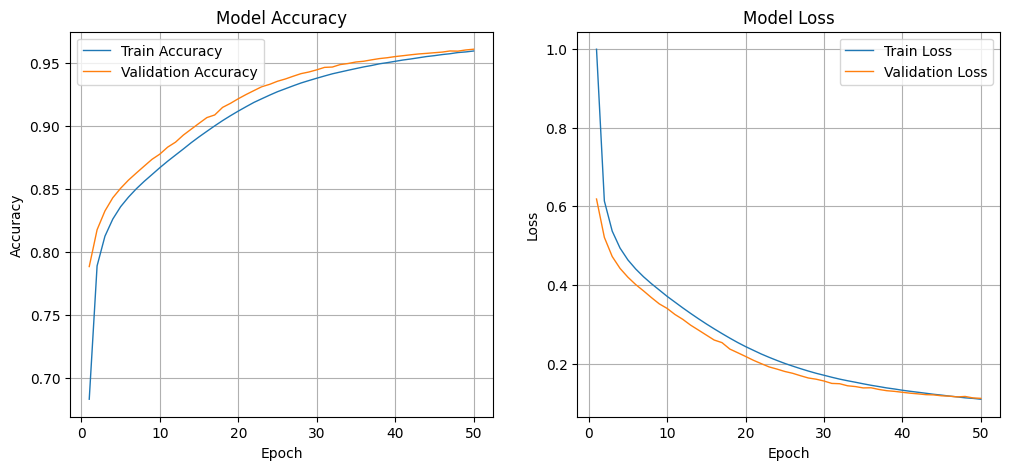

In [28]:
# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, label='Train Accuracy', linewidth=1)
plt.plot(epochs, val_accuracy, label='Validation Accuracy', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss', linewidth=1)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)